In [85]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#load the necessary odometry modules
from cpsl_datasets.cpsl_ds import CpslDS
from cpsl_datasets.map_handler import MapHandler
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.test_benches.point_cloud_integrator_tb import PointCloudIntegratorTB
from odometry.test_benches._test_bench import _TestBench, PredictionSource, GroundTruthSource, OdomCoordinateFrame
from odometry.point_cloud_processing.accumulation.integrators._pc_integrator import _PointCloudIntegrator
from odometry.point_cloud_processing.accumulation.integrators._pc_integrator_gnn_runner import _PointCloudIntegratorGnnRunner
from mmwave_model_integrator.model_runner.gnn_runner import GNNRunner
from mmwave_model_integrator.torch_training.models.TwoStreamSpatioTemporalGnn import TwoStreamSpatioTemporalGnn


from mmwave_model_integrator.dataset_generators._online_dataset_generator import _OnlineDatasetGenerator
from mmwave_model_integrator.input_encoders._node_encoder import _NodeEncoder
from mmwave_model_integrator.ground_truth_encoders._gt_node_encoder import _GTNodeEncoder

In [86]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
# MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")
# GENERATED_DATASETS_PATH=os.getenv("GENERATED_DATASETS_PATH")

DATASET_PATH = "/data/IcaRAus/datasets/UAV/Flow_datasets"
# DATASET_PATH = "/data/IcaRAus/datasets/UAV/Radar_datasets"
MAP_DIRECTORY = "/data/IcaRAus/maps"
GENERATED_DATASETS_PATH = "/data/IcaRAus/generated_datasets"

# #setup the datasets
folder_name = "vicon_box"
file_name = "vicon_box_3"
# file_name = "WILK_Multipath_Test_5" #for point cloud comparison (frame 1340)
# file_name = "WILK_Path_1_Same_Side_Dynamic_1"
# file_name = "wilk_basement_3" #wilk_basement_2 for point cloud processing (frame 780)

normalize_frames = True
num_frames_history = 50
config_label = "IcaRAus_gnn_{}fh_grids".format(num_frames_history)
results_parent_folder = "{}_train".format(config_label)

print(os.path.join(DATASET_PATH,folder_name,file_name))

dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_pc_folder="radar_combined_pc",
    camera_folder="camera",
    vehicle_odom_folder="vehicle_odom",
    vicon_folder="vicon_x500_8"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="north_vicon_1.yaml"#"cpsl_map.yaml"
)

/data/IcaRAus/datasets/UAV/Flow_datasets/vicon_box/vicon_box_3
found 1203 radar point cloud samples
did not find camera samples
found 1203 vehicle odometry samples
found 1203 vicon samples
loaded map from /data/IcaRAus/maps/north_vicon_1.yaml
loaded map free space from /data/IcaRAus/maps/north_vicon_1.yaml


In [87]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.25,#0.25
    icp_best_points_percentile=60, #60
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #7
    icp_max_iterations=5, #5
    self_detection_radius_m=0 #originally 0.0
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

In [88]:
#initialize the dataset encoders
input_encoder = _NodeEncoder()
gt_encoder = _GTNodeEncoder()

#initialize the dataset generator
generated_dataset_path = os.path.join(GENERATED_DATASETS_PATH,"{}_train".format(config_label))
dataset_generator = _OnlineDatasetGenerator(
    generated_dataset_path=generated_dataset_path,
    input_encoder=input_encoder,
    ground_truth_encoder=gt_encoder,
    generated_file_name="frame",
    input_encoding_folder="nodes",
    ground_truth_encoding_folder="labels",
    clear_existing_data=True
)

DatasetGenerator._check_for_directory: found directory /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train
DatasetGenerator._check_for_directory: clearing contents of /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train
DatasetGenerator._check_for_directory: found directory /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/nodes
DatasetGenerator._check_for_directory: clearing contents of /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/nodes
DatasetGenerator._check_for_directory: found directory /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/labels
DatasetGenerator._check_for_directory: clearing contents of /data/IcaRAus/generated_datasets/IcaRAus_gnn_50fh_grids_train/labels


In [89]:
#initialize the probabilistic point cloud grid
# point_cloud_integrator = _PointCloudIntegrator(
#     gt_distance_threshold_m=0.5,
#     num_frames_history=num_frames_history,
#     min_detection_radius=1.0,
#     max_detection_radius=4.0
# )

#if testing the gnn runner
model = TwoStreamSpatioTemporalGnn(
    hidden_channels=28,
    out_channels=1,
    k=4, #original is 40
    dropout=0.1
)

runner = GNNRunner(
    model= model,
    state_dict_path = "/home/david/Downloads/IcaRAus_TwoStreamSpatioTemporalGnn_IcaRAus_ds_50fh_k4.pth",
    cuda_device="cpu",
    edge_radius=10.0, #unused for this model
    enable_downsampling=True,
    downsample_keep_ratio=0.50,
    downsample_min_points=300,
    use_sigmoid=True
)

point_cloud_integrator = _PointCloudIntegratorGnnRunner(
    gnn_runner=runner,
    num_frames_history=num_frames_history,
    min_detection_radius=1.0,
    max_detection_radius=4.0,
    normalize_frames=True
)

#dynamic point cloud integrator
dynamic_point_cloud_integrator = _PointCloudIntegrator(
    gt_distance_threshold_m=0.5,
    num_frames_history=num_frames_history,
    min_detection_radius=1.0,
    max_detection_radius=4.0
)

_ModelRunner: using CPU
Total number of parameters: 19729


loaded map with 1921 points


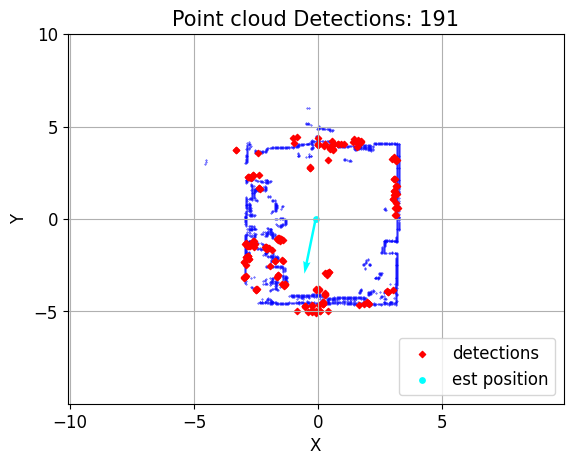

-98.70962651520564


In [90]:
test_bench = PointCloudIntegratorTB(
        localizer=radar_odometry,
        gt_localizer=lidar_odometry,
        map_handler=map_handler,
        dataset=dataset,
        point_cloud_integrator=point_cloud_integrator,
        dynamic_point_cloud_integrator=dynamic_point_cloud_integrator,
        model_dataset_generator=None,
        use_filters=True,
        prediction_source=PredictionSource.VEHICLE_ODOM,
        gt_source=GroundTruthSource.MOTION_CAPTURE,
        odom_frame=OdomCoordinateFrame.NED
    )

start_heading = np.deg2rad(0.0)
start_pose = np.array([0.0,0.0])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

print(np.rad2deg(new_heading_rad))


#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024 #originally -0.0024,
)

found temp dir: /home/david/Downloads/radnav_temp_dir/IcaRAus_gnn_50fh_grids_eval_odom
clearing temp directory /home/david/Downloads/radnav_temp_dir/IcaRAus_gnn_50fh_grids_eval_odom


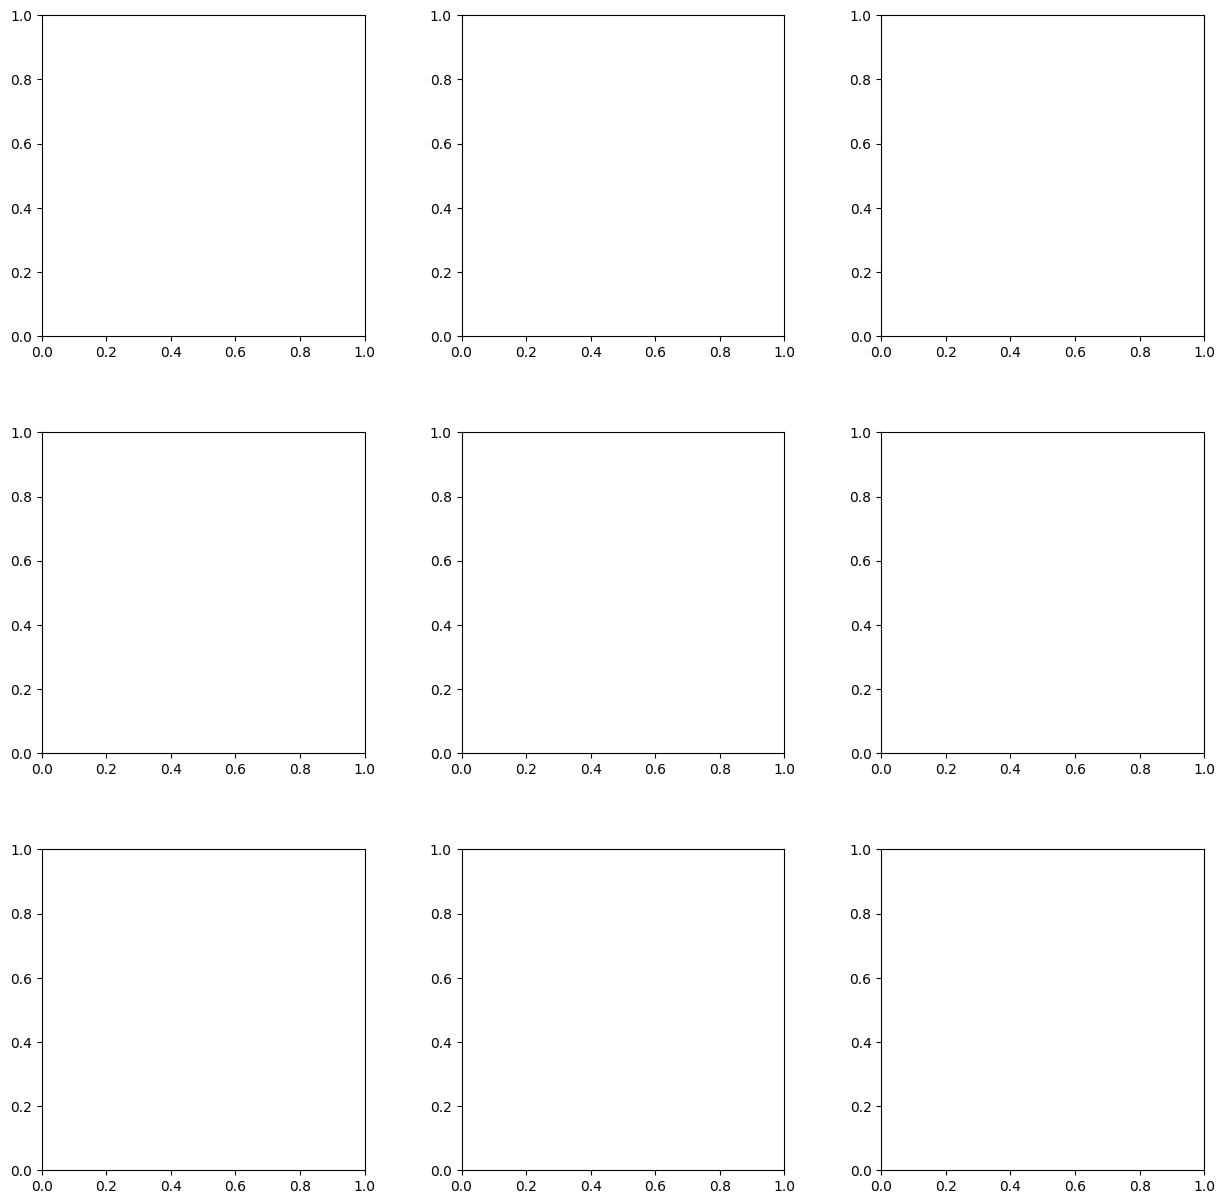

In [91]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=os.path.join(os.getenv("MOVIE_TEMP_DIRECTORY"),"{}_eval_odom".format(config_label))
)
movie_generator.initialize_figure(
    nrows=3,
    ncols=3,
    figsize=(15,15)
)

In [92]:
end_idx = 300#dataset.num_frames # for full dataset, use "dataset.num_frames" #point cloud sample: frame 1340 on Wilk_Multipath_test_5 (960 for pc compare, 980 for block diagram)
save_name = config_label + "radar_combined"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=True, #if not desired set to False
    movie_generator=None,
    generate_dataset=False) #use generator script in scripts folder instead

#run to around 1:07 mark for looking at the point cloud

100%|██████████| 300/300 [00:04<00:00, 62.67it/s]


In [54]:
# #evaluating processing times
# update_periods = np.array(test_bench.history_update_periods)
# processing_times = np.array(test_bench.history_update_actitve_compute_times)

# percent_processing_times = 100 * np.divide(processing_times, update_periods)
# np.save("processing_times/radnav.npy",percent_processing_times)

In [55]:
#save trajectories
# np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
np.save("Trajectories/RaGNNarok.npy",test_bench.history_position_m)

In [56]:
movie_generator.save_movie(video_file_name="{}_gnn.mp4".format(config_label),fps=20)

TypeError: MovieGenerator.save_movie() got an unexpected keyword argument 'video_file_name'

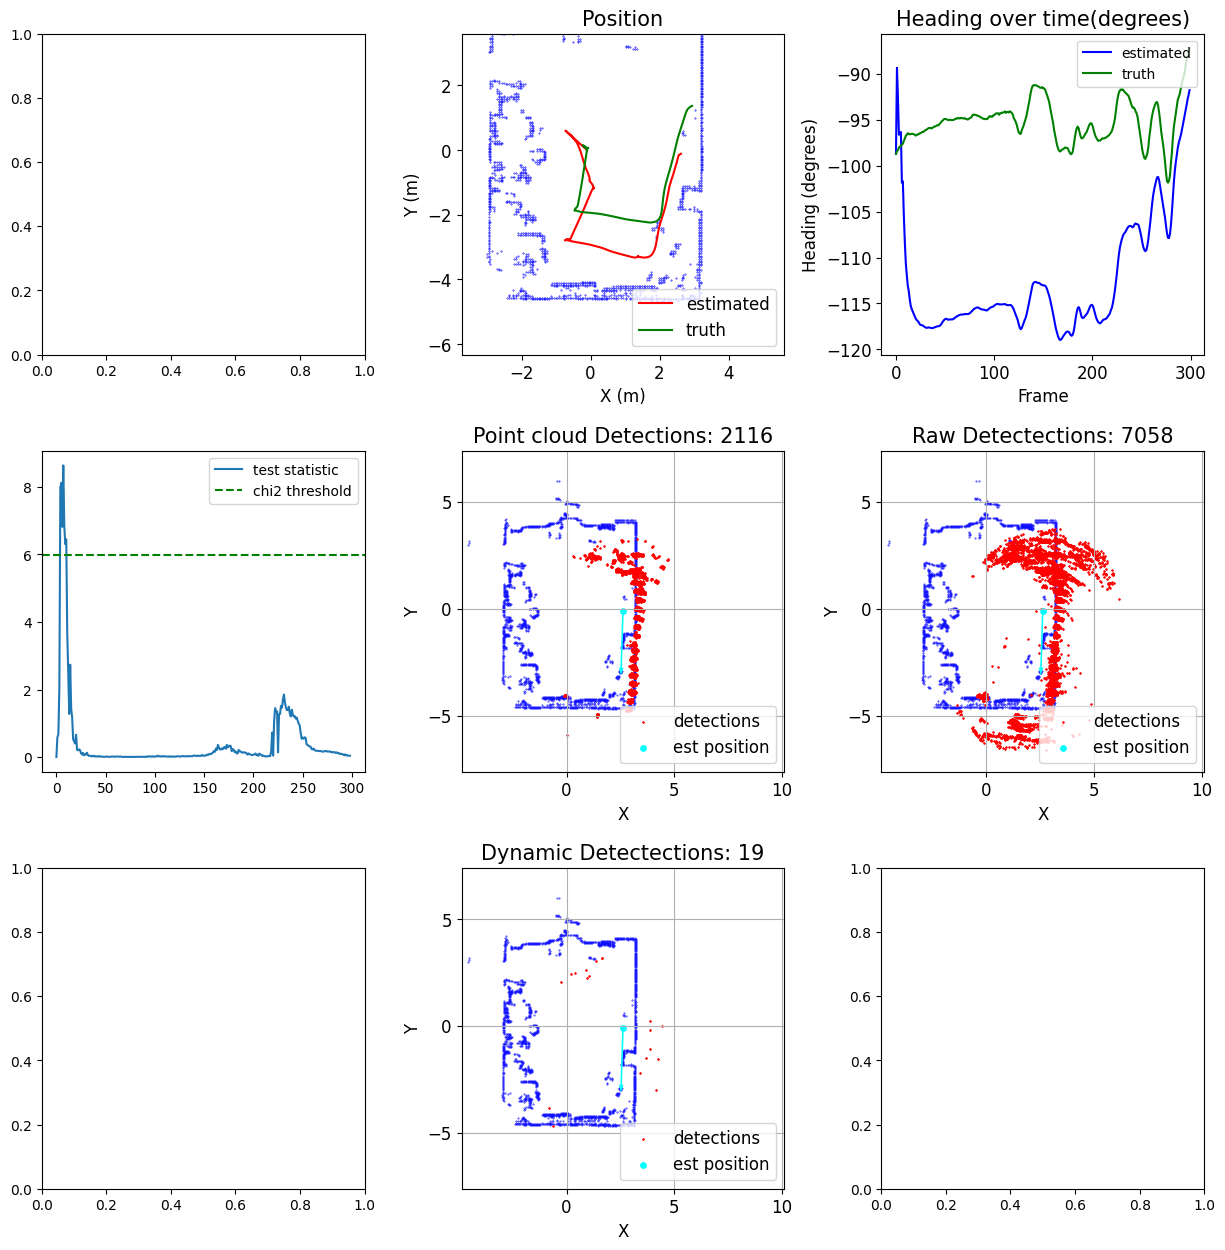

In [93]:
axs = test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

In [ ]:
import pandas as pd
import os

pc_quality_distances = test_bench.history_pc_quality_distances
save_folder = ""
file_name = config_label

df = pd.DataFrame.from_dict({"pc_quality_distances": [list(arr) for arr in pc_quality_distances]})
path = os.path.join(save_folder,file_name + "_pc_quality_distances.csv")
df.to_csv(path,index=False)

In [ ]:
test_bench.analyzer.record_error_statistics(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    test_bench.history_heading_deg,
    test_bench.history_heading_deg_gt,
    test_bench.history_pc_quality_distances,
    test_bench.history_pc_quality_num_quality_points,
    save_folder="",
    file_name=file_name
)

In [ ]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=config_label,
    export_to_csv=False
)

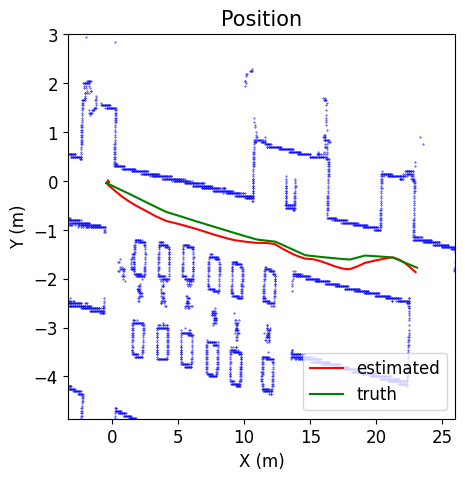

In [10]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

# fig.savefig("Images/position_history/{}.png".format(save_name))

In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

['map', 'detections', 'est position']


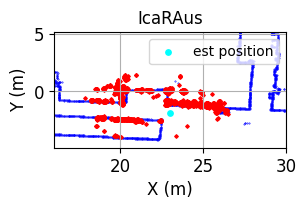

In [17]:
#visualizing the point cloud - for point cloud comparison
fig, axs = plt.subplots(figsize=(3,1.5))

combined_pc = test_bench.point_cloud_integrator.get_points()

test_bench.plotter_localization.marker_size = 3.0
test_bench.plotter_localization.plot_detections_on_map(
    current_points=combined_pc[:,0:2],
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=axs,
    show=False
) 
axs.set_title("IcaRAus",
                fontsize=test_bench.plotter_localization.font_size_legend)
axs.set_xlim(
    test_bench.filter.x[0] - 7,
    test_bench.filter.x[0] + 7)
axs.set_xlabel("X (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
axs.set_ylim(
    test_bench.filter.x[1] - 3,
    test_bench.filter.x[1] + 7)
axs.set_ylabel("Y (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
handles,labels = axs.get_legend_handles_labels()
print(labels)
axs.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)

plt.show()

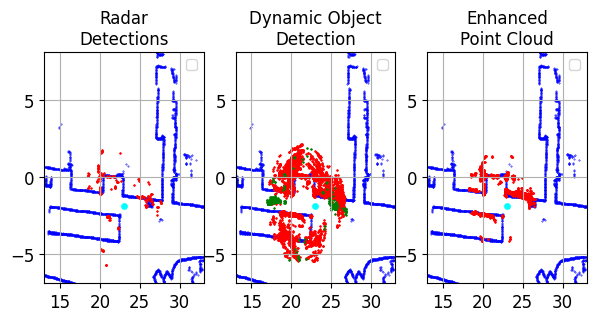

In [43]:
#visualizing the point cloud - for processing visualization
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(7,3))
plt.subplots_adjust(hspace=0.3)
#top left - single radar point cloud
ax=axs[0]
pc = dataset.get_radar_point_cloud(idx=end_idx)[:,0:2]
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
)
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:2], labels[2:2], loc="upper right",fontsize=10)
ax.set_title("Radar\nDetections",
                fontsize=test_bench.plotter_localization.font_size_legend)

# #bottom left - stacked point cloud
# combined_pc = test_bench.point_cloud_integrator.get_raw_point_history()[:,0:2]
# dynamic_combined_pc = test_bench.dynamic_point_cloud_integrator.get_raw_point_history()[:,0:2]
# print("combined_pc: {}, dynamic pc:{}".format(combined_pc.shape,dynamic_combined_pc.shape))
# test_bench.plotter_localization.marker_size = 0.5
# test_bench.plotter_localization.plot_detections_on_map(
#     current_points=np.append(combined_pc,dynamic_combined_pc,axis=0),
#     heading_rad=test_bench.filter.x[2],
#     pose_m=test_bench.filter.x[0:2],
#     ax=ax,
#     show=False
# ) 
# handles,labels = ax.get_legend_handles_labels()
# ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
# ax.set_title("Stacked Point Cloud",
#                 fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - velocities filtered
ax=axs[1]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_pc,
    dynamic_points=dynamic_combined_pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[1:1], labels[1:1], loc="upper right",fontsize=10)
ax.set_title("Dynamic Object\nDetection",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom right - final point cloud
pc = test_bench.point_cloud_integrator.get_points()[:,0:2]
ax=axs[2]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[1:1], labels[1:1], loc="upper right",fontsize=10)
ax.set_title("Enhanced\nPoint Cloud",
                fontsize=test_bench.plotter_localization.font_size_legend)

for r in range(3):
        axs[r].set_xlim(
            test_bench.filter.x[0] - 10,
            test_bench.filter.x[0] + 10)
        axs[r].set_xlabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)
        axs[r].set_ylim(
            test_bench.filter.x[1] - 5,
            test_bench.filter.x[1] + 10)
        axs[r].set_ylabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)

plt.show()

combined_pc: (7950, 2), dynamic pc:(458, 2)


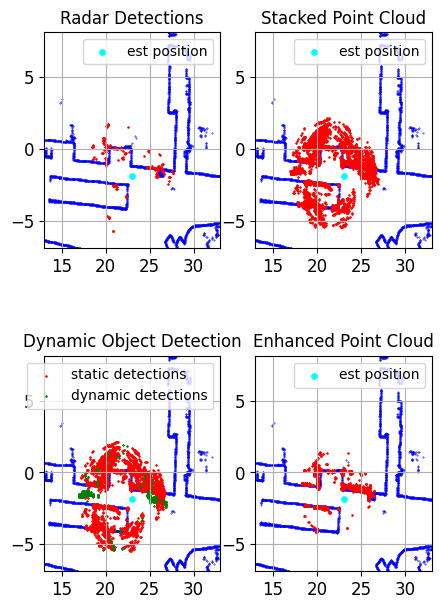

In [36]:
#visualizing the point cloud - for processing visualization
fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(5,7))
plt.subplots_adjust(hspace=0.5)
#top left - single radar point cloud
ax=axs[0,0]
pc = dataset.get_radar_point_cloud(idx=end_idx)[:,0:2]
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
)
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Radar Detections",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - stacked point cloud
ax=axs[0,1]
combined_pc = test_bench.point_cloud_integrator.get_raw_point_history()[:,0:2]
dynamic_combined_pc = test_bench.dynamic_point_cloud_integrator.get_raw_point_history()[:,0:2]
print("combined_pc: {}, dynamic pc:{}".format(combined_pc.shape,dynamic_combined_pc.shape))
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=np.append(combined_pc,dynamic_combined_pc,axis=0),
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Stacked Point Cloud",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - velocities filtered
ax=axs[1,0]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_pc,
    dynamic_points=dynamic_combined_pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[1:3], labels[1:3], loc="upper right",fontsize=10)
ax.set_title("Dynamic Object Detection",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom right - final point cloud
pc = test_bench.point_cloud_integrator.get_points()[:,0:2]
ax=axs[1,1]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Enhanced Point Cloud",
                fontsize=test_bench.plotter_localization.font_size_legend)

for r in range(2):
    for c in range(2):
        axs[r,c].set_xlim(
            test_bench.filter.x[0] - 10,
            test_bench.filter.x[0] + 10)
        axs[r,c].set_xlabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)
        axs[r,c].set_ylim(
            test_bench.filter.x[1] - 5,
            test_bench.filter.x[1] + 10)
        axs[r,c].set_ylabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)

plt.show()

In [ ]:
#visualizing the point cloud
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)


In [ ]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

In [ ]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

## Debugging (testing ray tracing)

In [ ]:
#timing analysis
pc_grid_static_orig = test_bench.point_cloud_stacker.pc_grid_static.copy()
pc_grid_dynamic_orig = test_bench.point_cloud_stacker.pc_grid_dynamic.copy()

for i in tqdm(range(500)):

    test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
    test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

    test_bench.point_cloud_stacker.refresh()

#reset the point cloud stacker:
test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

In [ ]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#recenter the point cloud grids
pc_grids_static = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_static,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)

pc_grid_dynamic = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_dynamic,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)


current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grids_static[0:1])
dynamic_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid_dynamic)

print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=current_points,
    dynamic_points = dynamic_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = \
    test_bench.point_cloud_stacker.vel_filtering.remove_dynamic_clusters_from_static_detections_knn(
        current_points,
        dynamic_points
    )

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#perform current multi-path
multipath_num_frames_history = 2

#update the static point grid
pc_grids_static[0] = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static[0:multipath_num_frames_history+1])

labels = test_bench.point_cloud_stacker.multi_path._cluster_points(current_points)

fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=current_points,
    labels=labels,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)


ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = test_bench.point_cloud_stacker.multi_path.remove_multipath(
    pc_cartesian=current_points
)

grid = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
pc_grids_static[0] = np.logical_and(grid,pc_grids_static[0])

current_points = test_bench.point_cloud_stacker._get_points_from_pc_grid(pc_grids_static[0])

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    valid_stacked_pc_cart = test_bench.point_cloud_stacker.multi_path.remove_multipath(current_points)

### Debugging ICP

In [ ]:
#get the point cloud (from the previous step)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static
)
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.filter.x[2],
    pose_m= test_bench.filter.x[0:2],
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#configure icp for only a single update
test_bench.localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.localizer.update_odometry(
        points=current_points,
        estimated_heading_rad=test_bench.filter.x[2],
        estimated_pose_m=test_bench.filter.x[0:2]
    )

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

### Evaluating processing time for lidar localization

In [ ]:
pc = dataset.get_lidar_point_cloud(idx=end_idx-1)

#configure icp for only a single update
test_bench.gt_localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.gt_localizer.update_odometry(
        points=pc[:,0:2],
        estimated_heading_rad=test_bench.filter_gt.x[2],
        estimated_pose_m=test_bench.filter_gt.x[0:2]
    )
print(pc.shape[0])